# CELL 1: IMPORTS + CONFIG

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os
import copy
import json
import math
import random
from dataclasses import dataclass
from typing import Optional, Tuple, List

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix


@dataclass
class Config:
    # KEEP YOUR CURRENT PATHS HERE EXACTLY AS YOU ALREADY HAVE THEM
    csv_path: str = "/content/drive/MyDrive/EADA/Datathon/train_val/Updated-Dataset.csv"
    image_dir: str = "/content/drive/MyDrive/EADA/Datathon/train_val/images"
    submission_test_dir: str = "/content/drive/MyDrive/EADA/Datathon/test_images"

    output_dir: str = "/content/drive/MyDrive/EADA/Datathon/train_val/Results"

    seed: int = 42
    img_size: int = 224
    batch_size: int = 8
    num_workers: int = 0

    val_size: float = 0.15
    test_size: float = 0.15

    frozen_epochs: int = 3
    finetune_epochs: int = 10

    head_lr: float = 5e-4
    backbone_lr: float = 3e-5
    weight_decay: float = 1e-4
    dropout: float = 0.20
    early_stop_patience: int = 4

    use_dataset_stats: bool = True
    stats_sample_size: Optional[int] = 1200

    target_sensitivity: float = 0.90
    target_specificity: float = 0.90

    device: str = "cpu"


CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CFG.seed)

print("Device:", CFG.device)
print("Output folder:", CFG.output_dir)

Device: cpu
Output folder: /content/drive/MyDrive/EADA/Datathon/train_val/Results


# Cell 2: DATA LOADING

In [17]:

def load_labels(csv_path: str, image_dir: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    required_cols = ["Image Index", "Finding Labels"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[["Image Index", "Finding Labels"]].copy()
    df.columns = ["image_name", "label"]

    df["image_name"] = df["image_name"].astype(str).str.strip()
    df["label"] = pd.to_numeric(df["label"], errors="coerce")

    df = df.dropna(subset=["label"]).copy()
    df["label"] = df["label"].astype(int)
    df = df[df["label"].isin([0, 1])].copy()

    df["image_path"] = df["image_name"].apply(lambda x: os.path.join(image_dir, x))

    missing_images = (~df["image_path"].apply(os.path.exists)).sum()
    if missing_images > 0:
        print("Missing images skipped:", missing_images)

    df = df[df["image_path"].apply(os.path.exists)].copy()
    df = df.drop_duplicates(subset=["image_name"]).reset_index(drop=True)

    if len(df) == 0:
        raise ValueError("No valid labeled images found.")

    print("Loaded rows:", len(df))
    print(df["label"].value_counts().sort_index())
    return df


def split_dataframe(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    train_df, temp_df = train_test_split(
        df,
        test_size=CFG.val_size + CFG.test_size,
        stratify=df["label"],
        random_state=CFG.seed,
    )

    rel_test_size = CFG.test_size / (CFG.val_size + CFG.test_size)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=rel_test_size,
        stratify=temp_df["label"],
        random_state=CFG.seed,
    )

    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def estimate_gray_mean_std(df: pd.DataFrame, sample_size: Optional[int] = 1000) -> Tuple[float, float]:
    sample_df = df
    if sample_size is not None and len(df) > sample_size:
        sample_df = df.sample(sample_size, random_state=CFG.seed)

    pixel_sum = 0.0
    pixel_sq_sum = 0.0
    pixel_count = 0

    for path in sample_df["image_path"]:
        img = Image.open(path).convert("L").resize((CFG.img_size, CFG.img_size))
        arr = np.asarray(img, dtype=np.float32) / 255.0
        pixel_sum += arr.sum()
        pixel_sq_sum += (arr ** 2).sum()
        pixel_count += arr.size

    mean = pixel_sum / pixel_count
    std = np.sqrt(max(pixel_sq_sum / pixel_count - mean ** 2, 1e-12))
    return float(mean), float(std)


full_df = load_labels(CFG.csv_path, CFG.image_dir)
train_df, val_df, test_df = split_dataframe(full_df)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

train_mean, train_std = estimate_gray_mean_std(train_df, CFG.stats_sample_size)
print("Estimated grayscale mean:", round(train_mean, 6))
print("Estimated grayscale std :", round(train_std, 6))

Loaded rows: 1578
label
0    858
1    720
Name: count, dtype: int64
Train: 1104 Val: 237 Test: 237
Estimated grayscale mean: 0.536137
Estimated grayscale std : 0.253105


# CELL 3: TRANSFORMS + DATASETS

In [18]:

def make_transforms(train_mean: float, train_std: float):
    if CFG.use_dataset_stats:
        mean = [train_mean, train_mean, train_mean]
        std = [train_std, train_std, train_std]
    else:
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    train_tf = T.Compose([
        T.Resize((CFG.img_size + 12, CFG.img_size + 12)),
        T.RandomCrop((CFG.img_size, CFG.img_size)),
        T.RandomAffine(degrees=5, translate=(0.02, 0.02), scale=(0.98, 1.02)),
        T.RandomApply([T.RandomAutocontrast()], p=0.30),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1)),
        T.Normalize(mean=mean, std=std),
    ])

    eval_tf = T.Compose([
        T.Resize((CFG.img_size, CFG.img_size)),
        T.ToTensor(),
        T.Lambda(lambda x: x.repeat(3, 1, 1)),
        T.Normalize(mean=mean, std=std),
    ])

    return train_tf, eval_tf


def make_tta_transforms(train_mean: float, train_std: float):
    if CFG.use_dataset_stats:
        mean = [train_mean, train_mean, train_mean]
        std = [train_std, train_std, train_std]
    else:
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

    return [
        T.Compose([
            T.Resize((CFG.img_size, CFG.img_size)),
            T.ToTensor(),
            T.Lambda(lambda x: x.repeat(3, 1, 1)),
            T.Normalize(mean=mean, std=std),
        ]),
        T.Compose([
            T.Resize((CFG.img_size + 12, CFG.img_size + 12)),
            T.CenterCrop((CFG.img_size, CFG.img_size)),
            T.ToTensor(),
            T.Lambda(lambda x: x.repeat(3, 1, 1)),
            T.Normalize(mean=mean, std=std),
        ]),
        T.Compose([
            T.Resize((CFG.img_size + 20, CFG.img_size + 20)),
            T.CenterCrop((CFG.img_size, CFG.img_size)),
            T.ToTensor(),
            T.Lambda(lambda x: x.repeat(3, 1, 1)),
            T.Normalize(mean=mean, std=std),
        ]),
    ]


class CardiomegalyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("L")
        if self.transform is not None:
            img = self.transform(img)
        label = torch.tensor(float(row["label"]), dtype=torch.float32)
        return img, label, row["image_name"]


class SubmissionDataset(Dataset):
    def __init__(self, image_dir: str, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_file = self.image_files[idx]
        image_path = os.path.join(self.image_dir, image_file)
        img = Image.open(image_path).convert("L")
        if self.transform is not None:
            img = self.transform(img)
        return img, image_file


train_tf, eval_tf = make_transforms(train_mean, train_std)

train_ds = CardiomegalyDataset(train_df, transform=train_tf)
val_ds = CardiomegalyDataset(val_df, transform=eval_tf)
test_ds = CardiomegalyDataset(test_df, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)

# CELL 4: MODEL + TRAINING + METRICS

In [19]:

def build_model(dropout: float = 0.20):
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(1280, 1)
    )
    return model


def freeze_backbone(model):
    for p in model.features.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model


def unfreeze_last_blocks(model, n_blocks: int = 8):
    total_blocks = len(model.features)
    start_idx = max(0, total_blocks - n_blocks)
    for i, block in enumerate(model.features):
        requires_grad = i >= start_idx
        for p in block.parameters():
            p.requires_grad = requires_grad
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model


def run_epoch(model, loader, criterion=None, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    losses = []
    all_y_true = []
    all_y_prob = []
    all_names = []

    for batch in loader:
        images, labels, names = batch
        images = images.to(CFG.device)
        labels = labels.to(CFG.device)

        with torch.set_grad_enabled(is_train):
            logits = model(images).squeeze(1)
            loss = criterion(logits, labels) if criterion is not None else None
            probs = torch.sigmoid(logits)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if loss is not None:
            losses.append(loss.item())

        all_y_true.extend(labels.detach().cpu().numpy())
        all_y_prob.extend(probs.detach().cpu().numpy())
        all_names.extend(list(names))

    all_y_true = np.array(all_y_true, dtype=np.float32)
    all_y_prob = np.array(all_y_prob, dtype=np.float32)
    all_y_pred = (all_y_prob >= 0.5).astype(int)

    out = {
        "loss": float(np.mean(losses)) if len(losses) > 0 else np.nan,
        "auc": float(roc_auc_score(all_y_true, all_y_prob)) if len(np.unique(all_y_true)) > 1 else np.nan,
        "acc": float((all_y_pred == all_y_true).mean()),
        "y_true": all_y_true,
        "y_prob": all_y_prob,
        "y_pred": all_y_pred,
        "names": all_names,
    }
    return out


def run_epoch_tta(model, df: pd.DataFrame, tta_transforms):
    all_probs = []
    final_names = None
    final_y_true = None

    for tf in tta_transforms:
        ds = CardiomegalyDataset(df, transform=tf)
        loader = DataLoader(ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)
        out = run_epoch(model, loader, criterion=None, optimizer=None)
        all_probs.append(out["y_prob"])

        if final_names is None:
            final_names = out["names"]
            final_y_true = out["y_true"]

    mean_prob = np.mean(np.stack(all_probs, axis=0), axis=0)
    mean_pred = (mean_prob >= 0.5).astype(int)

    return {
        "loss": np.nan,
        "auc": float(roc_auc_score(final_y_true, mean_prob)) if len(np.unique(final_y_true)) > 1 else np.nan,
        "acc": float((mean_pred == final_y_true).mean()),
        "y_true": final_y_true,
        "y_prob": mean_prob,
        "y_pred": mean_pred,
        "names": final_names,
    }


def predict_submission_tta(model, submission_dir: str, tta_transforms):
    all_probs = []
    final_names = None

    for tf in tta_transforms:
        ds = SubmissionDataset(submission_dir, transform=tf)
        loader = DataLoader(ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=False)

        model.eval()
        fold_probs = []
        fold_names = []

        with torch.no_grad():
            for images, names in loader:
                images = images.to(CFG.device)
                logits = model(images).squeeze(1)
                probs = torch.sigmoid(logits).detach().cpu().numpy()
                fold_probs.extend(probs)
                fold_names.extend(list(names))

        all_probs.append(np.array(fold_probs))

        if final_names is None:
            final_names = fold_names

    mean_prob = np.mean(np.stack(all_probs, axis=0), axis=0)

    return {
        "names": final_names,
        "y_prob": mean_prob
    }


def compute_basic_metrics(y_true, y_prob, threshold: float):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    youden = sensitivity + specificity - 1.0
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan

    return {
        "threshold": float(threshold),
        "auc": float(auc),
        "sensitivity": float(sensitivity),
        "specificity": float(specificity),
        "youden": float(youden),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "tp": int(tp),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
    }


def find_best_threshold(y_true, y_prob, mode="youden"):
    candidates = np.unique(np.round(y_prob, 6))
    candidates = np.concatenate(([0.0], candidates, [1.0]))
    rows = [compute_basic_metrics(y_true, y_prob, thr) for thr in candidates]
    tab = pd.DataFrame(rows)

    if mode == "youden":
        best_row = tab.sort_values(["youden", "auc", "accuracy"], ascending=[False, False, False]).iloc[0]

    elif mode == "target_sensitivity":
        good = tab[tab["sensitivity"] >= CFG.target_sensitivity]
        if len(good) > 0:
            best_row = good.sort_values(["specificity", "youden"], ascending=[False, False]).iloc[0]
        else:
            best_row = tab.iloc[(tab["sensitivity"] - CFG.target_sensitivity).abs().argsort()].iloc[0]

    elif mode == "target_specificity":
        good = tab[tab["specificity"] >= CFG.target_specificity]
        if len(good) > 0:
            best_row = good.sort_values(["sensitivity", "youden"], ascending=[False, False]).iloc[0]
        else:
            best_row = tab.iloc[(tab["specificity"] - CFG.target_specificity).abs().argsort()].iloc[0]

    else:
        raise ValueError("mode must be one of: youden, target_sensitivity, target_specificity")

    return float(best_row["threshold"]), tab


def train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs, stage_name):
    best_score = -np.inf
    best_state = None
    patience_counter = 0
    history = []

    for epoch in range(1, epochs + 1):
        train_out = run_epoch(model, train_loader, criterion, optimizer)
        val_out = run_epoch(model, val_loader, criterion, optimizer=None)

        score = val_out["auc"] if not np.isnan(val_out["auc"]) else val_out["acc"]

        if scheduler is not None:
            scheduler.step(score)

        history.append({
            "stage": stage_name,
            "epoch": epoch,
            "train_loss": train_out["loss"],
            "train_auc": train_out["auc"],
            "val_loss": val_out["loss"],
            "val_auc": val_out["auc"],
            "val_acc": val_out["acc"],
        })

        print(
            f"{stage_name} | epoch {epoch}/{epochs} | "
            f"train_loss={train_out['loss']:.4f} | "
            f"val_loss={val_out['loss']:.4f} | "
            f"val_auc={val_out['auc']:.4f} | "
            f"val_acc={val_out['acc']:.4f}"
        )

        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= CFG.early_stop_patience:
                print("Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

# CELL 5: TRAIN

In [ ]:

criterion = nn.BCEWithLogitsLoss()

model = build_model(CFG.dropout).to(CFG.device)

# Stage 1: frozen
model = freeze_backbone(model)

optimizer_frozen = optim.AdamW(
    model.classifier.parameters(),
    lr=CFG.head_lr,
    weight_decay=CFG.weight_decay
)

scheduler_frozen = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_frozen,
    mode="max",
    factor=0.5,
    patience=1
)

model, hist_frozen = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_frozen,
    scheduler=scheduler_frozen,
    epochs=CFG.frozen_epochs,
    stage_name="frozen"
)

# Stage 2: fine-tune
model = unfreeze_last_blocks(model, n_blocks=8)

backbone_params = [p for p in model.features.parameters() if p.requires_grad]
head_params = [p for p in model.classifier.parameters() if p.requires_grad]

optimizer_ft = optim.AdamW(
    [
        {"params": backbone_params, "lr": CFG.backbone_lr},
        {"params": head_params, "lr": CFG.head_lr},
    ],
    weight_decay=CFG.weight_decay
)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode="max",
    factor=0.5,
    patience=1
)

model, hist_ft = train_stage(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_ft,
    scheduler=scheduler_ft,
    epochs=CFG.finetune_epochs,
    stage_name="finetune"
)

history_df = pd.concat([hist_frozen, hist_ft], ignore_index=True)
history_df.to_csv(os.path.join(CFG.output_dir, "training_history.csv"), index=False)

model_path = os.path.join(CFG.output_dir, "best_model.pth")
torch.save(model.state_dict(), model_path)
print("Saved model to:", model_path)

frozen | epoch 1/3 | train_loss=0.6839 | val_loss=0.6317 | val_auc=0.7161 | val_acc=0.6203
frozen | epoch 2/3 | train_loss=0.6261 | val_loss=0.5960 | val_auc=0.7735 | val_acc=0.6835
frozen | epoch 3/3 | train_loss=0.6092 | val_loss=0.5703 | val_auc=0.7936 | val_acc=0.6751
finetune | epoch 1/10 | train_loss=0.5584 | val_loss=0.4665 | val_auc=0.8765 | val_acc=0.7426
finetune | epoch 2/10 | train_loss=0.4763 | val_loss=0.4289 | val_auc=0.8943 | val_acc=0.7764
finetune | epoch 3/10 | train_loss=0.4225 | val_loss=0.3856 | val_auc=0.9066 | val_acc=0.8101
finetune | epoch 4/10 | train_loss=0.3931 | val_loss=0.4025 | val_auc=0.8983 | val_acc=0.8017
finetune | epoch 5/10 | train_loss=0.4002 | val_loss=0.3783 | val_auc=0.9120 | val_acc=0.8059


# CELL 6: TTA EVALUATION + THRESHOLDS

In [24]:

tta_transforms = make_tta_transforms(train_mean, train_std)

val_out = run_epoch_tta(model, val_df, tta_transforms)
test_out = run_epoch_tta(model, test_df, tta_transforms)

print("Validation AUC with TTA:", round(val_out["auc"], 4))
print("Test AUC with TTA:", round(test_out["auc"], 4))

thr_youden, tab_youden = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="youden")
thr_sens, tab_sens = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="target_sensitivity")
thr_spec, tab_spec = find_best_threshold(val_out["y_true"], val_out["y_prob"], mode="target_specificity")

threshold_summary = pd.DataFrame([
    {"mode": "youden", **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_youden)},
    {"mode": "target_sensitivity", **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_sens)},
    {"mode": "target_specificity", **compute_basic_metrics(val_out["y_true"], val_out["y_prob"], thr_spec)},
])

threshold_summary = threshold_summary[
    ["mode", "threshold", "auc", "sensitivity", "specificity", "youden", "accuracy", "precision", "tp", "tn", "fp", "fn"]
]

threshold_summary.to_csv(os.path.join(CFG.output_dir, "threshold_summary.csv"), index=False)
display(threshold_summary)

# best threshold for balancing sensitivity + specificity
best_threshold = thr_youden
print("Using threshold for final predictions:", round(best_threshold, 4))

val_metrics_final = compute_basic_metrics(val_out["y_true"], val_out["y_prob"], best_threshold)
test_metrics_final = compute_basic_metrics(test_out["y_true"], test_out["y_prob"], best_threshold)

with open(os.path.join(CFG.output_dir, "val_metrics_final.json"), "w") as f:
    json.dump(val_metrics_final, f, indent=2)

with open(os.path.join(CFG.output_dir, "test_metrics_final.json"), "w") as f:
    json.dump(test_metrics_final, f, indent=2)

print("Validation final metrics:")
print(val_metrics_final)

print("Test final metrics:")
print(test_metrics_final)

val_pred_df = pd.DataFrame({
    "image_name": val_out["names"],
    "y_true": val_out["y_true"].astype(int),
    "prob": val_out["y_prob"],
    "pred": (val_out["y_prob"] >= best_threshold).astype(int),
})
val_pred_df.to_csv(os.path.join(CFG.output_dir, "val_predictions.csv"), index=False)

test_pred_df = pd.DataFrame({
    "image_name": test_out["names"],
    "y_true": test_out["y_true"].astype(int),
    "prob": test_out["y_prob"],
    "pred": (test_out["y_prob"] >= best_threshold).astype(int),
})
test_pred_df.to_csv(os.path.join(CFG.output_dir, "test_predictions.csv"), index=False)

Validation AUC with TTA: 0.9293
Test AUC with TTA: 0.9363


,mode,threshold,auc,sensitivity,specificity,youden,accuracy,precision,tp,tn,fp,fn
0,youden,0.432885,0.929299,0.879630,0.837209,0.716839,0.856540,0.818966,95,108,21,13
1,target_sensitivity,0.304120,0.929299,0.907407,0.775194,0.682601,0.835443,0.771654,98,100,29,10
2,target_specificity,0.666808,0.929299,0.740741,0.906977,0.647717,0.831224,0.869565,80,117,12,28


Using threshold for final predictions: 0.4329
Validation final metrics:
{'threshold': 0.43288499116897583, 'auc': 0.9292994544932529, 'sensitivity': 0.8796296296296297, 'specificity': 0.8372093023255814, 'youden': 0.7168389319552111, 'accuracy': 0.8565400843881856, 'precision': 0.8189655172413793, 'tp': 95, 'tn': 108, 'fp': 21, 'fn': 13}
Test final metrics:
{'threshold': 0.43288499116897583, 'auc': 0.9363336204421475, 'sensitivity': 0.8703703703703703, 'specificity': 0.8449612403100775, 'youden': 0.7153316106804479, 'accuracy': 0.8565400843881856, 'precision': 0.8245614035087719, 'tp': 94, 'tn': 109, 'fp': 20, 'fn': 14}


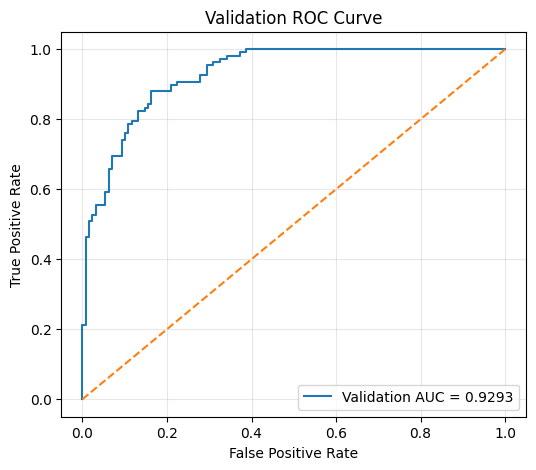

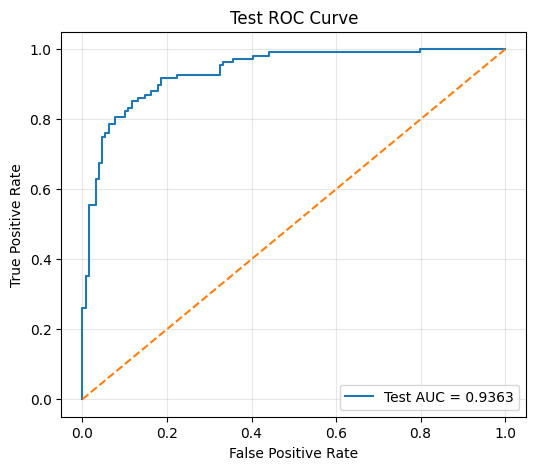

In [25]:
# ============================================================
# ROC CURVES: VALIDATION + TEST
# ============================================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Validation ROC
val_fpr, val_tpr, _ = roc_curve(val_out["y_true"], val_out["y_prob"])
val_auc = auc(val_fpr, val_tpr)

plt.figure(figsize=(6, 5))
plt.plot(val_fpr, val_tpr, label=f"Validation AUC = {val_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Test ROC
test_fpr, test_tpr, _ = roc_curve(test_out["y_true"], test_out["y_prob"])
test_auc = auc(test_fpr, test_tpr)

plt.figure(figsize=(6, 5))
plt.plot(test_fpr, test_tpr, label=f"Test AUC = {test_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# CELL 7: DAILY SUBMISSION

In [26]:

submission_out = predict_submission_tta(model, CFG.submission_test_dir, tta_transforms)

submission_df = pd.DataFrame({
    "image_file": submission_out["names"],
    "prob": submission_out["y_prob"],
})
submission_df["pred"] = (submission_df["prob"] >= best_threshold).astype(int)

submission_path = os.path.join(CFG.output_dir, "daily_submission.csv")
submission_df.to_csv(submission_path, index=False)

print("Saved daily submission to:", submission_path)
print("Total rows:", len(submission_df))
submission_df.head()


Saved daily submission to: /content/drive/MyDrive/EADA/Datathon/train_val/Results/daily_submission.csv
Total rows: 176


,image_file,prob,pred
0,IMG_000018.png,0.464056,1
1,IMG_000021.png,0.011916,0
2,IMG_000039.png,0.388455,0
3,IMG_000044.png,0.273537,0
4,IMG_000047.png,0.547440,1
